# 13.1 Bitly Data from 1.USA.gov

## 1. Giới thiệu dữ liệu

In [94]:
# data đầu vào
path = "example.txt"

In [95]:
# đọc file và lưu vào list records
import json
with open(path) as f:
    records = [json.loads(line) for line in f]

In [96]:
import pandas as pd
# chuyển records thành dataframe
frame = pd.DataFrame(records)

In [97]:
# hiển thị thông tin dataframe
frame.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3560 entries, 0 to 3559
Data columns (total 18 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   a            3440 non-null   object 
 1   c            2919 non-null   object 
 2   nk           3440 non-null   float64
 3   tz           3440 non-null   object 
 4   gr           2919 non-null   object 
 5   g            3440 non-null   object 
 6   h            3440 non-null   object 
 7   l            3440 non-null   object 
 8   al           3094 non-null   object 
 9   hh           3440 non-null   object 
 10  r            3440 non-null   object 
 11  u            3440 non-null   object 
 12  t            3440 non-null   float64
 13  hc           3440 non-null   float64
 14  cy           2919 non-null   object 
 15  ll           2919 non-null   object 
 16  _heartbeat_  120 non-null    float64
 17  kw           93 non-null     object 
dtypes: float64(4), object(14)
memory usage: 500.8+ K

### Sơ lược về các giá trị
| **Trường** | **Ý nghĩa**               | **Ví dụ giá trị**                                            | **Giải thích cụ thể**                                                                          |
| ---------- | ------------------------- | ------------------------------------------------------------ | ---------------------------------------------------------------------------------------------- |
| **`a`**    | Agent (User-Agent string) | `'Mozilla/5.0 (Windows NT 6.1; WOW64)...Chrome/17.0.963.78'` | Thông tin trình duyệt và hệ điều hành của người dùng (ở đây: Chrome 17 trên Windows 7 64-bit). |
| **`al`**   | Accepted Language         | `'en-US,en;q=0.8'`                                           | Ngôn ngữ trình duyệt — ở đây là tiếng Anh (Mỹ).                                                |
| **`c`**    | Country code              | `'US'`                                                       | Mã quốc gia theo chuẩn ISO (người dùng đến từ Hoa Kỳ).                                         |
| **`cy`**   | City                      | `'Danvers'`                                                  | Tên thành phố (Danvers, bang Massachusetts).                                                   |
| **`gr`**   | Geographic region         | `'MA'`                                                       | Mã bang hoặc vùng địa lý (MA = Massachusetts).                                                 |
| **`tz`**   | Time zone                 | `'America/New_York'`                                         | Múi giờ của người dùng, dùng cho thống kê thời gian hoạt động.                                 |
| **`ll`**   | Latitude & Longitude      | `[42.576698, -70.954903]`                                    | Tọa độ địa lý (vĩ độ, kinh độ).                                                                |
| **`r`**    | Referrer URL              | `'http://www.facebook.com/.../1.usa.gov/wfLQtf'`             | Trang web mà người dùng truy cập **trước khi** click link Bitly (ở đây là từ Facebook).        |
| **`u`**    | Target URL (destination)  | `'http://www.ncbi.nlm.nih.gov/pubmed/22415991'`              | Liên kết gốc (trang web đích sau khi rút gọn).                                                 |
| **`hh`**   | Host name                 | `'1.usa.gov'`                                                | Domain chính của liên kết rút gọn.                                                             |
| **`g`**    | Global hash               | `'A6qOVH'`                                                   | Mã định danh toàn cục của URL rút gọn (Bitly ID).                                              |
| **`h`**    | Short hash                | `'wfLQtf'`                                                   | Mã rút gọn thực tế của URL (dạng sau “bit.ly/”).                                               |
| **`l`**    | Login                     | `'orofrog'`                                                  | Tên người dùng (Bitly login) tạo liên kết rút gọn.                                             |
| **`hc`**   | Hash creation time        | `1331822918`                                                 | Thời gian (UNIX timestamp) khi liên kết được tạo.                                              |
| **`t`**    | Click time                | `1331923247`                                                 | Thời gian (UNIX timestamp) khi có lượt click.                                                  |
| **`nk`**   | Unknown numeric key       | `1`                                                          | Cờ (flag) kỹ thuật nội bộ Bitly, thường biểu thị trạng thái hợp lệ.                            |


## 2️. Thống kê mô tả và phân tích dữ liệu

### 2.1. Phân bố người dùng theo múi giờ và quốc gia

Phân tích tần suất truy cập theo trường tz và c.

In [98]:
# đếm số các giá trị trong cột tz
tz_counts = frame["tz"].value_counts()
# hiển thì giá trị đếm được của các dòng đầu tiên
tz_counts.head()

tz
America/New_York       1251
                        521
America/Chicago         400
America/Los_Angeles     382
America/Denver          191
Name: count, dtype: int64

In [99]:
# Xử lý giá trị thiếu trong cột tz
clean_tz = frame["tz"].fillna("Missing")
clean_tz[clean_tz == ""] = "Unknown"

In [100]:
# đếm lại các giá tri trong cột tz sau khi đã xử lý giá trị thiếu
tz_counts = clean_tz.value_counts()
tz_counts.head()

tz
America/New_York       1251
Unknown                 521
America/Chicago         400
America/Los_Angeles     382
America/Denver          191
Name: count, dtype: int64

In [101]:
# đếm số các giá trị trong cột c
c_counts = frame["c"].value_counts()
# hiển thì giá trị đếm được của các dòng đầu tiên
c_counts.head()

c
US    2305
GB      74
CA      60
ES      37
JP      37
Name: count, dtype: int64

#### Nhận xét:

Đa số người dùng đến từ Hoa Kỳ, tập trung ở múi giờ America/New_York.

Một phần nhỏ từ Canada, Anh ,Nhật Bản, Tây Ban Nha.

### 2.2. Thống kê hệ điều hành người dùng

Trích xuất từ chuỗi a (User-Agent).

In [102]:
# lọc bỏ các dòng có giá trị thiếu trong cột a
cframe = frame[frame['a'].notna()].copy()

In [103]:
# hàm phát hiện hệ điều hành từ chuỗi user agent
def detect_os(agent):
    agent = agent.lower()
    if 'windows' in agent: return 'Windows'
    elif 'mac' in agent: return 'Mac'
    elif 'android' in agent: return 'Android'
    elif 'linux' in agent: return 'Linux'
    else: return 'Khác'

cframe['Hệ điều hành'] = cframe['a'].apply(detect_os)

In [104]:
# Đếm số lượt theo hệ điều hành
os_counts = cframe['Hệ điều hành'].value_counts()

# Tính phần trăm (%)
os_percent = (os_counts / os_counts.sum() * 100).round(1)

# Tạo DataFrame hiển thị
os_summary = pd.DataFrame({
    'Hệ điều hành': os_counts.index,
    'Số lượt': os_counts.values,
    'Tỷ lệ (%)': os_percent.values
})

# Hiển thị kết quả
os_summary

,Hệ điều hành,Số lượt,Tỷ lệ (%)
0,Windows,2246,65.3
1,Mac,773,22.5
2,Khác,254,7.4
3,Android,131,3.8
4,Linux,36,1.0


#### Nhận xét:

Windows là nền tảng chiếm đa số (~2/3 người dùng).

Mac và Android đứng sau, cho thấy người dùng Bitly chủ yếu trên máy tính cá nhân.

### 2.3. Nguồn referrer phổ biến

In [105]:
# Xử lý dữ liệu: chỉ lấy trường 'r' (referrer)
frame['r'] = frame['r'].fillna('Unknown')

# Hàm trích xuất tên miền referrer
def extract_domain(url):
    if not isinstance(url, str):
        return 'Unknown'
    if '://' in url:
        try:
            return url.split('/')[2]
        except IndexError:
            return 'Unknown'
    return 'direct' if url == 'direct' else 'Unknown'

# Tạo cột tên miền referrer
frame['referrer_domain'] = frame['r'].apply(extract_domain)

# Đếm số lượt theo tên miền
ref_counts = frame['referrer_domain'].value_counts()

# Tính tỷ lệ phần trăm
ref_percent = (ref_counts / ref_counts.sum() * 100).round(1)

# Tạo bảng thống kê mô tả
ref_summary = pd.DataFrame({
    'Referrer': ref_percent.index,
    'Tỷ lệ (%)': ref_percent.values
}).head(10)

ref_summary


,Referrer,Tỷ lệ (%)
0,direct,44.5
1,t.co,14.7
2,www.facebook.com,13.0
3,twitter.com,4.3
4,www.AwareMap.com,3.4
5,Unknown,3.4
6,www.shrewsbury-ma.gov,2.5
7,m.facebook.com,2.4
8,plus.url.google.com,1.2
9,togetter.com,0.8


### 2.4. Mức độ lan truyền của liên kết (g / h)



In [106]:
# Loại bỏ dòng thiếu dữ liệu 'g' hoặc 'h'
frame = frame.dropna(subset=['g', 'h'])

# Nhóm theo mã global 'g' và đếm số lượng mã 'h' duy nhất
spread = frame.groupby('g')['h'].nunique().sort_values(ascending=False)

# Lấy top 10 mã có nhiều link nhất
top_spread = spread.head(10).reset_index()
top_spread.columns = ['Mã g', 'Số link h']

# Hiển thị bảng kết quả
top_spread

,Mã g,Số link h
0,zCaLwp,6
1,wCUeMo,3
2,Ag7vNh,2
3,AAxNkt,2
4,Au3aUS,2
5,h4inTS,2
6,wdO6ZT,2
7,wdYv2F,2
8,x20N,2
9,xKlxpf,2


Nhận xét (cho bảng trên):

Mã zCaLwp có 6 liên kết con (h) → đây là liên kết có mức lan truyền mạnh nhất, được nhiều người dùng khác nhau rút gọn hoặc chia sẻ lại.

Các mã như wCUeMo (3 liên kết) và nhóm mã có 2 liên kết (Ag7vNh, AAxNkt, Au3aUS, v.v.) thể hiện mức độ lan truyền thấp hơn, tức là chỉ được chia sẻ lại một vài lần.

Đa số mã g chỉ có 2 liên kết con, cho thấy phần lớn các liên kết Bitly chỉ được rút gọn một vài lần và không lan truyền rộng rãi.

Tổng thể, chỉ một số ít liên kết có tính "viral" (lan truyền mạnh), còn lại là các liên kết ít được chia sẻ lại, phù hợp với quy luật tự nhiên của nội dung mạng xã hội:

Một số nội dung “hot” được lan truyền rộng, trong khi phần lớn các link chỉ có ít lượt chia sẻ.

## 3️. Trực quan hóa dữ liệu

### 3.1. Biểu đồ phân bố múi giờ

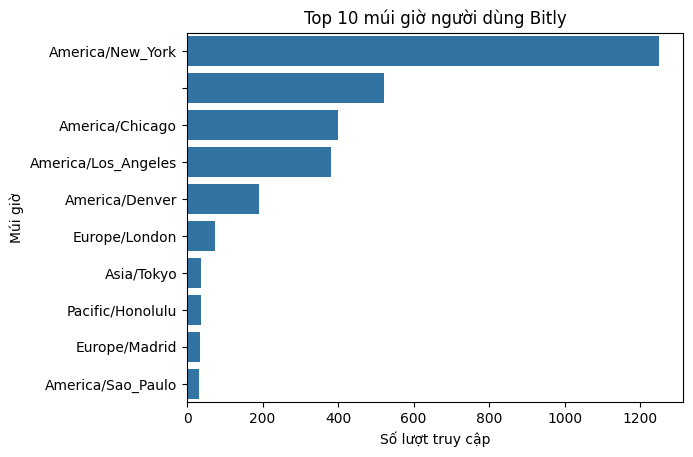

In [110]:
tz_counts = frame['tz'].value_counts().head(10)  # Top 10

sns.barplot(y=tz_counts.index, x=tz_counts.values)
plt.title('Top 10 múi giờ người dùng Bitly')
plt.xlabel('Số lượt truy cập')
plt.ylabel('Múi giờ')
plt.show()

### 3.2. Biểu đồ hệ điều hành

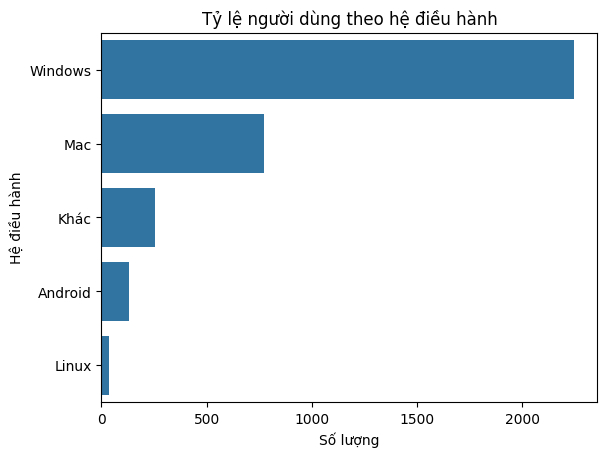

In [ ]:

sns.barplot(y=os_counts.index, x=os_counts.values)
plt.title('Tỷ lệ người dùng theo hệ điều hành')
plt.xlabel('Số lượng')
plt.ylabel('Hệ điều hành')
plt.show()



### 3.3. Biểu đồ nguồn referrer

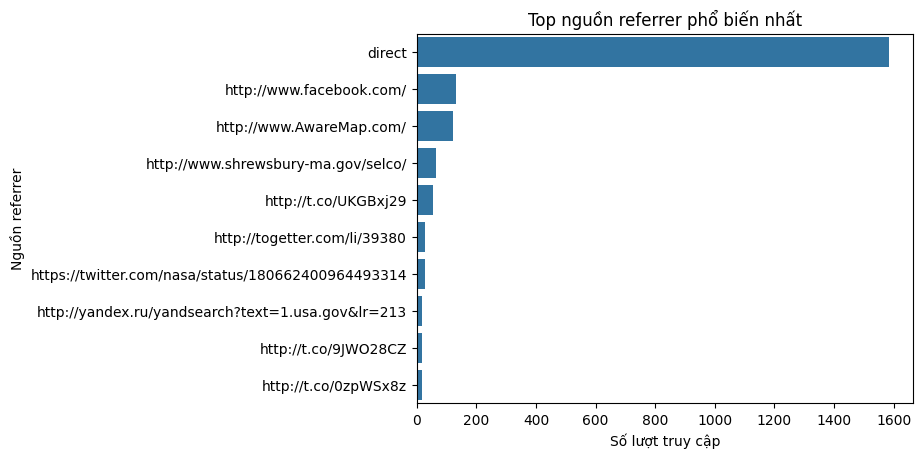

In [114]:
ref_counts = frame['r'].value_counts().head(10)  # Top 10
sns.barplot(y=ref_counts.index, x=ref_counts.values)
plt.title('Top nguồn referrer phổ biến nhất')
plt.xlabel('Số lượt truy cập')
plt.ylabel('Nguồn referrer')
plt.show()


### 3.4. Biểu đồ lan truyền link

<class 'pandas.core.series.Series'>
g
zCaLwp    6
wCUeMo    3
Ag7vNh    2
AAxNkt    2
Au3aUS    2
h4inTS    2
wdO6ZT    2
wdYv2F    2
x20N      2
xKlxpf    2
Name: h, dtype: int64


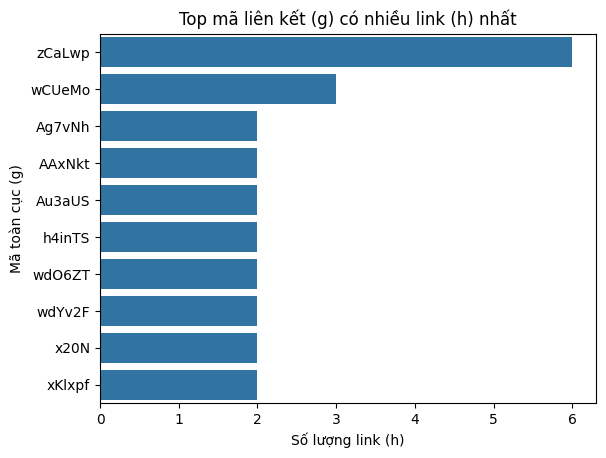

In [117]:
link_spread = frame.groupby('g')['h'].nunique().sort_values(ascending=False)

# Kiểm tra kiểu dữ liệu (phải là pandas Series)
print(type(link_spread))

# Hiển thị top 10 mã lan truyền nhất
print(link_spread.head(10))

# 🔹 Vẽ biểu đồ top 10
sns.barplot(x=link_spread.head(10).values, y=link_spread.head(10).index)
plt.title('Top mã liên kết (g) có nhiều link (h) nhất')
plt.xlabel('Số lượng link (h)')
plt.ylabel('Mã toàn cục (g)')
plt.show()